# Assignment 2 - Part B: Fine-Tuning

Pick the best model from Part A and fine-tune it by unfreezing pretrained
backbone layers while keeping the trained head frozen.

It is my goal to experiment with unfreezing at least 2 different layers of the model to compare how deeper vs shallower feature adjustments affect the final accuracy.

## 1. Setup

In [1]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor

import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import v2
from torchvision.datasets.folder import default_loader
from torch.utils.data import DataLoader, Dataset, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True
torch.manual_seed(42)

## 2. Data Preparation

[2.1] Download dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

download_dir = '/content/drive/MyDrive/94691/data/'
os.makedirs(download_dir, exist_ok=True)
os.chdir(download_dir)

url = 'http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz'

if not os.path.exists('food-101.tar.gz'):
    !wget --no-clobber {url}

local_dir = '/content/food-101'
# If we unpack it is approx. 101000 files...
if not os.path.exists(local_dir):
    !tar -xzkvf food-101.tar.gz -C /content/ | tqdm --total 101000 --desc "Extracting" > /dev/null

!ls -l /content/food-101/images | wc -l

Mounted at /content/drive
102


[2.2] Resize dataset to 256x256 (Matching Part A)

In [3]:
src_dir = '/content/food-101/images'
dest_dir = '/content/food-101-256/images'

all_files = []
if os.path.exists(src_dir):
    for root, _, files in os.walk(src_dir):
        for f in files:
            if f.endswith('.jpg'):
                rel_path = os.path.relpath(os.path.join(root, f), src_dir)
                if not os.path.exists(os.path.join(dest_dir, rel_path)):
                    all_files.append(rel_path)

def process_image(rel_path):
    src_path = os.path.join(src_dir, rel_path)
    dest_path = os.path.join(dest_dir, rel_path)
    os.makedirs(os.path.dirname(dest_path), exist_ok=True)
    try:
        with Image.open(src_path) as img:
            img = img.convert('RGB')
            w, h = img.size
            if w < h:
                new_w = 256
                new_h = int(256 * h / w)
            else:
                new_h = 256
                new_w = int(256 * w / h)
            img = img.resize((new_w, new_h), Image.BILINEAR)
            img.save(dest_path, format='JPEG', quality=95)
    except Exception as e:
        print(f"Error on {rel_path}: {e}")

if len(all_files) > 0:
    print(f"Processing {len(all_files)} images to 256x256...")
    with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
        list(tqdm(executor.map(process_image, all_files), total=len(all_files)))
    print("Finished creating 256x256 dataset!")
else:
    print("256x256 dataset already exists.")

Processing 101000 images to 256x256...


100%|██████████| 101000/101000 [07:40<00:00, 219.18it/s]

Finished creating 256x256 dataset!


[2.3] Prepare optimized DataLoader splits and CPU/GPU transforms

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

data_dir_256 = "/content/food-101-256"
meta_dir = os.path.join(local_dir, "meta")

class Food101Split(Dataset):
    def __init__(self, root, split_file, transform=None):
        self.root = root
        self.transform = transform
        self.loader = default_loader

        with open(split_file, "r") as f:
            entries = [line.strip() for line in f.readlines()]

        classes = sorted(set(e.split("/")[0] for e in entries))
        self.class_to_idx = {c: i for i, c in enumerate(classes)}

        self.samples = []
        for entry in entries:
            class_name = entry.split("/")[0]
            path = os.path.join(root, "images", f"{entry}.jpg")
            self.samples.append((path, self.class_to_idx[class_name]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = self.loader(path)
        if self.transform:
            img = self.transform(img)
        return img, label

class DatasetWrapper(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# CPU Transforms (Keep as uint8 to save PCIe bandwidth)
cpu_train_transforms = torch.nn.Sequential(
    v2.ToImage(),
    v2.RandomCrop(224),
)

cpu_eval_transforms = torch.nn.Sequential(
    v2.ToImage(),
    v2.CenterCrop(224),
)

# GPU Transforms (Augmentations, float32 conversion, normalization)
gpu_train_transforms = torch.nn.Sequential(
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(15),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
).to(device)

gpu_eval_transforms = torch.nn.Sequential(
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
).to(device)

train_full = Food101Split(data_dir_256, os.path.join(meta_dir, "train.txt"))
test_dataset_raw = Food101Split(data_dir_256, os.path.join(meta_dir, "test.txt"))

train_size = int(0.85 * len(train_full))
val_size = len(train_full) - train_size
train_subset, val_subset = random_split(train_full, [train_size, val_size])

batch_size = 128
num_workers = os.cpu_count()

train_loader = DataLoader(
    DatasetWrapper(train_subset, cpu_train_transforms),
    batch_size=batch_size, num_workers=num_workers, shuffle=True,
    pin_memory=True, persistent_workers=True
)
val_loader = DataLoader(
    DatasetWrapper(val_subset, cpu_eval_transforms),
    batch_size=batch_size, num_workers=num_workers, shuffle=False,
    pin_memory=True, persistent_workers=True
)
test_loader = DataLoader(
    DatasetWrapper(test_dataset_raw, cpu_eval_transforms),
    batch_size=batch_size, num_workers=num_workers, shuffle=False,
    pin_memory=True, persistent_workers=True
)

print(f"Train: {len(train_subset)}  |  Val: {val_size}  |  Test: {len(test_dataset_raw)}")

Using device: cuda
Train: 64387  |  Val: 11363  |  Test: 25250


## 3. Load best model from Part A

In [5]:
weights_dir = "/content/drive/MyDrive/94691/models-15-epochs/"

model = torchvision.models.mobilenet_v3_large(weights=None)
model.classifier = nn.Sequential(
    nn.Linear(960, 1024), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(1024, 512), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(512, 101),
)

# model_path = os.path.join(weights_dir, "MobileNetV3_food101_last.pth")
model_path = os.path.join(weights_dir, "MobileNetV3_best_food101.pth")
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Loaded Part A weights from {model_path}")
else:
    print(f"Warning: Could not find weights at {model_path}. Starting from scratch.")

# Defining layers to experiment with.
# deeper layers (15, 16) contain high-level semantic features
# shallower layers (11, 12) contain mid-level patterns
layer_experiments = ["features.16", "features.15", "features.12", "features.11"]

Loaded Part A weights from /content/drive/MyDrive/94691/models-15-epochs/MobileNetV3_best_food101.pth


## 4. Training and Evaluation helpers

Reused mostly from AT2 part A.


In [6]:
criterion = nn.CrossEntropyLoss()

class CustomCallback:
    def __init__(self, early_stop_patience, reduce_lr_factor, reduce_lr_patience, reduce_lr_min_lr, checkpoint_prefix):
        self.early_stop_patience = early_stop_patience
        self.reduce_lr_factor = reduce_lr_factor
        self.reduce_lr_patience = reduce_lr_patience
        self.reduce_lr_min_lr = reduce_lr_min_lr
        self.checkpoint_prefix = checkpoint_prefix

        self.early_stop_counter = 0
        self.best_val_loss = float('inf')
        self.optimizer = None
        self.scheduler = None

    def set_optimizer(self, optimizer):
        self.optimizer = optimizer

    def set_model(self, model):
        self.model = model

    def on_train_begin(self):
        self.scheduler = ReduceLROnPlateau(
            self.optimizer, mode='min',
            factor=self.reduce_lr_factor,
            patience=self.reduce_lr_patience,
            min_lr=self.reduce_lr_min_lr
        )

    def on_epoch_end(self, epoch, val_loss):
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.early_stop_counter = 0

            if self.model is not None:
                checkpoint_path = f"{self.checkpoint_prefix}_best.pth"
                torch.save(self.model.state_dict(), checkpoint_path)
                print(f"    * Validation loss improved to {val_loss:.4f}. Saved {checkpoint_path}")
        else:
            self.early_stop_counter += 1

        if self.early_stop_counter >= self.early_stop_patience:
            print("Early stopping triggered!")
            return True

        if self.scheduler is not None:
            self.scheduler.step(val_loss)

        return False

def trainOneEpoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    pbar = tqdm(dataloader, desc="Training", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        images = gpu_train_transforms(images)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)

        if hasattr(outputs, "logits"):
            outputs = outputs.logits

        loss = criterion(outputs, labels.long())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predicted = torch.argmax(outputs, dim=1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

        current_acc = correct_train / total_train
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{current_acc:.2%}")

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct_train / total_train
    return epoch_loss, epoch_acc

def validateOneEpoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_val = 0
    total_val = 0

    pbar = tqdm(dataloader, desc="Validating", leave=False)
    with torch.no_grad():
        for images, labels in pbar:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            images = gpu_eval_transforms(images)

            outputs = model(images)

            loss = criterion(outputs, labels.long())
            running_loss += loss.item()

            predicted = torch.argmax(outputs, dim=1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)

            current_acc = correct_val / total_val
            pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{current_acc:.2%}")

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct_val / total_val
    return epoch_loss, epoch_acc

def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, title):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Training Loss", marker="o")
    plt.plot(epochs, val_losses, label="Validation Loss", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Losses")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label="Training Accuracy", marker="o")
    plt.plot(epochs, val_accuracies, label="Validation Accuracy", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracies")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

## 5. Fine-tuning experiments

For each experiment we:
1. Start from the Part A trained weights
2. Freeze everything (including the trained head)
3. Unfreeze only the target backbone layer
4. Train with a low learning rate to fine-tune the representations


Fine-tuning Experiment: unfreezing 'features.16'
Trainable parameters: 155,520 / 4,532,629 (3.43%)


Epoch [1/15] | Train Loss: 1.8132 | Train Acc: 53.46% | Val Loss: 1.6918 | Val Acc: 57.76% | LR: 0.000050
    * Validation loss improved to 1.6918. Saved /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_16_best.pth


Epoch [2/15] | Train Loss: 1.7824 | Train Acc: 54.25% | Val Loss: 1.6759 | Val Acc: 58.14% | LR: 0.000050
    * Validation loss improved to 1.6759. Saved /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_16_best.pth


Epoch [3/15] | Train Loss: 1.7616 | Train Acc: 54.62% | Val Loss: 1.6682 | Val Acc: 58.27% | LR: 0.000050
    * Validation loss improved to 1.6682. Saved /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_16_best.pth


Epoch [4/15] | Train Loss: 1.7516 | Train Acc: 54.90% | Val Loss: 1.6518 | Val Acc: 58.49% | LR: 0.000050
    * Validation loss improved to 1.6518. Saved /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_16_best.pth


...

Epoch [11/15] | Train Loss: 1.6496 | Train Acc: 57.27% | Val Loss: 1.6244 | Val Acc: 59.28% | LR: 0.000025
    * Validation loss improved to 1.6244. Saved /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_16_best.pth


Epoch [12/15] | Train Loss: 1.6637 | Train Acc: 56.53% | Val Loss: 1.6274 | Val Acc: 59.21% | LR: 0.000025


Epoch [13/15] | Train Loss: 1.6696 | Train Acc: 56.70% | Val Loss: 1.6236 | Val Acc: 59.28% | LR: 0.000025
    * Validation loss improved to 1.6236. Saved /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_16_best.pth


Epoch [14/15] | Train Loss: 1.6730 | Train Acc: 56.59% | Val Loss: 1.6302 | Val Acc: 59.12% | LR: 0.000025


Epoch [15/15] | Train Loss: 1.6813 | Train Acc: 56.25% | Val Loss: 1.6445 | Val Acc: 58.88% | LR: 0.000025


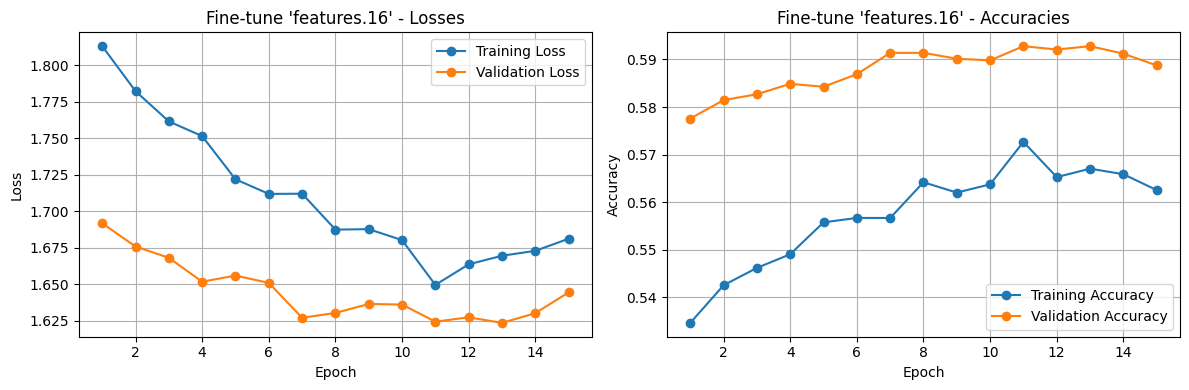

Loaded best weights for testing from /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_16_best.pth
Evaluating finetuned model (unfrozen: features.16) on Test Dataset...


--> Test Loss: 1.3628 | Test Acc: 64.06%


Fine-tuning Experiment: unfreezing 'features.15'
Trainable parameters: 797,360 / 4,532,629 (17.59%)


Epoch [1/15] | Train Loss: 1.7610 | Train Acc: 54.72% | Val Loss: 1.6280 | Val Acc: 59.48% | LR: 0.000050
    * Validation loss improved to 1.6280. Saved /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_15_best.pth


Epoch [2/15] | Train Loss: 1.6881 | Train Acc: 56.28% | Val Loss: 1.6076 | Val Acc: 59.89% | LR: 0.000050
    * Validation loss improved to 1.6076. Saved /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_15_best.pth


Epoch [3/15] | Train Loss: 1.6562 | Train Acc: 56.74% | Val Loss: 1.6004 | Val Acc: 59.95% | LR: 0.000050
    * Validation loss improved to 1.6004. Saved /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_15_best.pth


...

Epoch [11/15] | Train Loss: 1.4910 | Train Acc: 60.66% | Val Loss: 1.5205 | Val Acc: 61.71% | LR: 0.000050


Epoch [12/15] | Train Loss: 1.4960 | Train Acc: 60.40% | Val Loss: 1.5090 | Val Acc: 62.11% | LR: 0.000050


Epoch [13/15] | Train Loss: 1.4658 | Train Acc: 61.31% | Val Loss: 1.4886 | Val Acc: 62.29% | LR: 0.000025
    * Validation loss improved to 1.4886. Saved /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_15_best.pth


Epoch [14/15] | Train Loss: 1.4626 | Train Acc: 61.15% | Val Loss: 1.4825 | Val Acc: 62.48% | LR: 0.000025
    * Validation loss improved to 1.4825. Saved /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_15_best.pth


Epoch [15/15] | Train Loss: 1.4445 | Train Acc: 61.65% | Val Loss: 1.4826 | Val Acc: 62.55% | LR: 0.000025


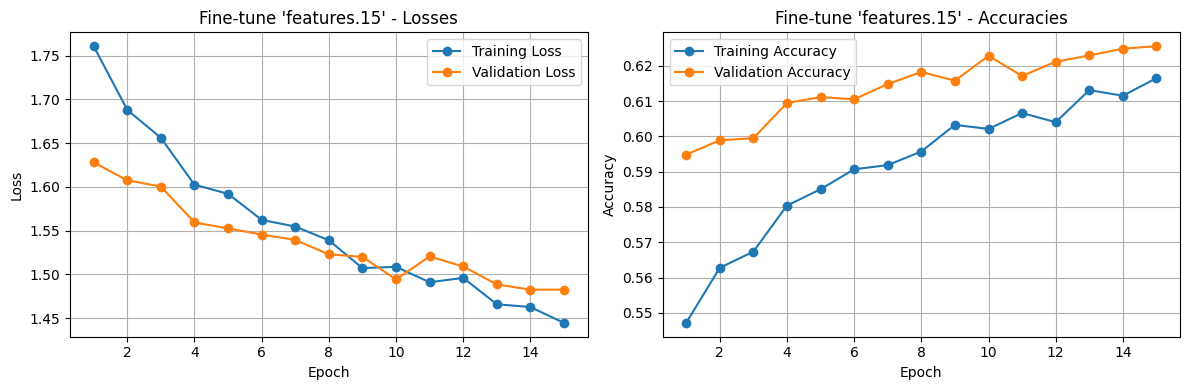

Loaded best weights for testing from /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_15_best.pth
Evaluating finetuned model (unfrozen: features.15) on Test Dataset...


--> Test Loss: 1.2174 | Test Acc: 67.38%


Fine-tuning Experiment: unfreezing 'features.12'
Trainable parameters: 386,120 / 4,532,629 (8.52%)


Epoch [1/15] | Train Loss: 1.7113 | Train Acc: 55.97% | Val Loss: 1.6541 | Val Acc: 58.45% | LR: 0.000050
    * Validation loss improved to 1.6541. Saved /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_12_best.pth


Epoch [2/15] | Train Loss: 1.6240 | Train Acc: 57.79% | Val Loss: 1.6391 | Val Acc: 58.94% | LR: 0.000050
    * Validation loss improved to 1.6391. Saved /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_12_best.pth


Epoch [3/15] | Train Loss: 1.5884 | Train Acc: 58.61% | Val Loss: 1.6280 | Val Acc: 59.19% | LR: 0.000050
    * Validation loss improved to 1.6280. Saved /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_12_best.pth


...

Epoch [11/15] | Train Loss: 1.4569 | Train Acc: 61.61% | Val Loss: 1.5573 | Val Acc: 60.92% | LR: 0.000050
    * Validation loss improved to 1.5573. Saved /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_12_best.pth


Epoch [12/15] | Train Loss: 1.4396 | Train Acc: 62.20% | Val Loss: 1.5676 | Val Acc: 60.86% | LR: 0.000050


Epoch [13/15] | Train Loss: 1.4250 | Train Acc: 62.46% | Val Loss: 1.5575 | Val Acc: 61.01% | LR: 0.000050


Epoch [14/15] | Train Loss: 1.4354 | Train Acc: 61.92% | Val Loss: 1.5605 | Val Acc: 61.16% | LR: 0.000025


Epoch [15/15] | Train Loss: 1.4181 | Train Acc: 62.59% | Val Loss: 1.5398 | Val Acc: 61.66% | LR: 0.000025
    * Validation loss improved to 1.5398. Saved /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_12_best.pth


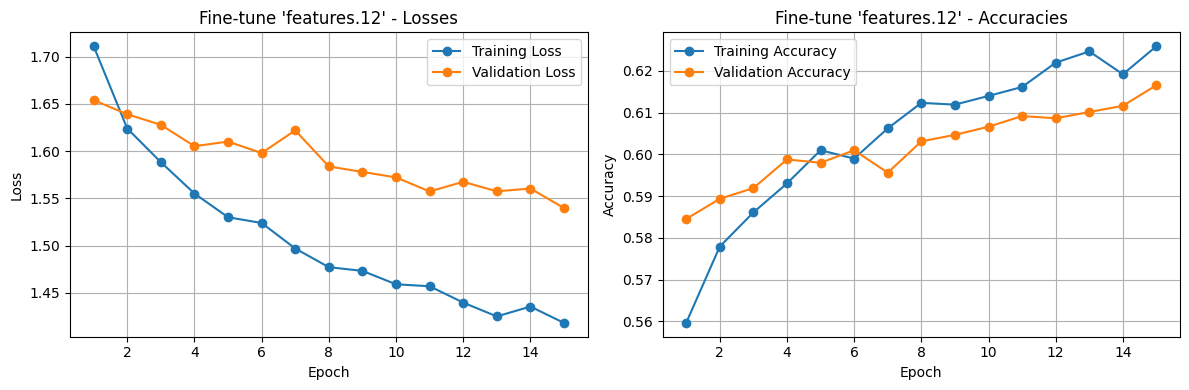

Loaded best weights for testing from /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_12_best.pth
Evaluating finetuned model (unfrozen: features.12) on Test Dataset...


--> Test Loss: 1.2662 | Test Acc: 66.32%


Fine-tuning Experiment: unfreezing 'features.11'
Trainable parameters: 214,424 / 4,532,629 (4.73%)


Epoch [1/15] | Train Loss: 1.7681 | Train Acc: 54.71% | Val Loss: 1.6865 | Val Acc: 57.85% | LR: 0.000050
    * Validation loss improved to 1.6865. Saved /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_11_best.pth


Epoch [2/15] | Train Loss: 1.6518 | Train Acc: 57.35% | Val Loss: 1.6637 | Val Acc: 58.33% | LR: 0.000050
    * Validation loss improved to 1.6637. Saved /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_11_best.pth


Epoch [3/15] | Train Loss: 1.6210 | Train Acc: 57.91% | Val Loss: 1.6727 | Val Acc: 58.07% | LR: 0.000050


...

Epoch [7/15] | Train Loss: 1.5456 | Train Acc: 59.61% | Val Loss: 1.6254 | Val Acc: 59.42% | LR: 0.000050
    * Validation loss improved to 1.6254. Saved /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_11_best.pth


Epoch [8/15] | Train Loss: 1.5351 | Train Acc: 59.68% | Val Loss: 1.6404 | Val Acc: 59.16% | LR: 0.000050


Epoch [9/15] | Train Loss: 1.5105 | Train Acc: 60.36% | Val Loss: 1.6293 | Val Acc: 59.55% | LR: 0.000050


Epoch [10/15] | Train Loss: 1.5175 | Train Acc: 60.09% | Val Loss: 1.6374 | Val Acc: 59.14% | LR: 0.000025


Epoch [11/15] | Train Loss: 1.5123 | Train Acc: 60.46% | Val Loss: 1.6345 | Val Acc: 59.14% | LR: 0.000025
Early stopping triggered!


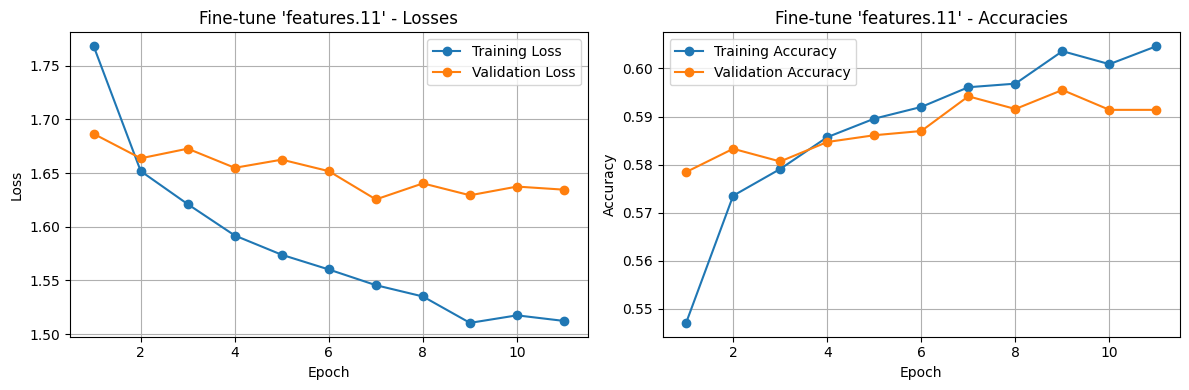

Loaded best weights for testing from /content/drive/MyDrive/94691/models-finetune/MobileNetV3_features_11_best.pth
Evaluating finetuned model (unfrozen: features.11) on Test Dataset...


--> Test Loss: 1.3606 | Test Acc: 64.17%



In [7]:
num_epochs = 15
all_results = {}
save_path = "/content/drive/MyDrive/94691/models-finetune/"
os.makedirs(save_path, exist_ok=True)

for layer_name in layer_experiments:
    print(f"\n{'='*50}")
    print(f"Fine-tuning Experiment: unfreezing '{layer_name}'")
    print(f"{'='*50}")

    ft_model = copy.deepcopy(model)

    for param in ft_model.parameters():
        param.requires_grad = False

    for name, param in ft_model.named_parameters():
        if layer_name in name:
            param.requires_grad = True

    trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in ft_model.parameters())
    print(f"Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

    ft_model.to(device)

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, ft_model.parameters()),
        lr=5e-5,
    )

    checkpoint_prefix = os.path.join(save_path, f"MobileNetV3_{layer_name.replace('.', '_')}")

    custom_callback = CustomCallback(
        early_stop_patience=4,
        reduce_lr_factor=0.5,
        reduce_lr_patience=1,
        reduce_lr_min_lr=1e-6,
        checkpoint_prefix=checkpoint_prefix
    )
    custom_callback.set_optimizer(optimizer)
    custom_callback.set_model(ft_model)
    custom_callback.on_train_begin()

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    best_val_acc = 0.0

    for epoch in range(num_epochs):
        train_loss, train_acc = trainOneEpoch(ft_model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validateOneEpoch(ft_model, val_loader, criterion, device)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2%} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2%} | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc

        if custom_callback.on_epoch_end(epoch, val_loss):
            break

    plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies,
                 f"Fine-tune '{layer_name}'")

    best_checkpoint = f"{checkpoint_prefix}_best.pth"
    if os.path.exists(best_checkpoint):
        ft_model.load_state_dict(torch.load(best_checkpoint))
        print(f"Loaded best weights for testing from {best_checkpoint}")

    print(f"Evaluating finetuned model (unfrozen: {layer_name}) on Test Dataset...")
    test_loss, test_acc = validateOneEpoch(ft_model, test_loader, criterion, device)
    print(f"--> Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2%}\n")

    all_results[layer_name] = {
        "best_val_acc": best_val_acc,
        "test_acc": test_acc,
        "checkpoint_path": best_checkpoint
    }

## 6. Comparison & Final Analysis

In [8]:
print(f"\n{'='*45}")
print(f"FINAL FINE-TUNING RESULTS")
print(f"{'='*45}")
print(f"{'Layer Unfrozen':<20} {'Best Val Acc':>12} {'Test Acc':>10}")
print("-" * 45)
for layer_name, res in all_results.items():
    print(f"{layer_name:<20} {res['best_val_acc']:>11.2%} {res['test_acc']:>9.2%}")

best_layer = max(all_results, key=lambda k: all_results[k]["test_acc"])
print(f"\nBest performing layer architecture adjustments isolated to: {best_layer}")
print(f"Checkpoints preserved in Google Drive at {save_path}")


FINAL FINE-TUNING RESULTS
Layer Unfrozen       Best Val Acc   Test Acc
---------------------------------------------
features.16               59.28%    64.06%
features.15               62.55%    67.38%
features.12               61.66%    66.32%
features.11               59.55%    64.17%

Best performing layer architecture adjustments isolated to: features.15
Checkpoints preserved safely in Google Drive at /content/drive/MyDrive/94691/models-finetune/
